In [17]:
import numpy as np
unmoda = "/root/sunxh/WaveCrossMamba/dataset/fine.ivt.unmod.a.tsv"
unmodc = "/root/sunxh/WaveCrossMamba/dataset/fine.ivt.unmod.c.tsv"
unmodu = "/root/sunxh/WaveCrossMamba/dataset/fine.ivt.unmod.u.tsv"
unmodg = "/root/sunxh/WaveCrossMamba/dataset/fine.ivt.unmod.g.tsv"
m6a = "/root/sunxh/WaveCrossMamba/dataset/fine.ivt.m6a.tsv"
m1a = "/root/sunxh/WaveCrossMamba/dataset/fine.ivt.m1a.tsv"
inosine = "/root/sunxh/WaveCrossMamba/dataset/fine.ivt.inosine.tsv"
m5c = "/root/sunxh/WaveCrossMamba/dataset/fine.ivt.m5c.tsv"
hm5c = "/root/sunxh/WaveCrossMamba/dataset/fine.ivt.hm5c.tsv"
m7g = "/root/sunxh/WaveCrossMamba/dataset/IVT_m7G.feature.tsv"
psu = "/root/sunxh/WaveCrossMamba/dataset/fine.ivt.psu.tsv"
kmer_encode_dic={'A': 0, "C": 1, "G": 2, "T": 3}

def load_predict_data(file, max_length=500, signal_length=500):
    X, signals = [], []
    count = 0
    with open(file) as f:
        for line in f:
            line = line.rstrip()
            items = line.split("\t")

 
            raw_signals = "|".join(items[9:14]).split("|")
            signal = np.array([float(s) for s in raw_signals])

 
 

 
            if len(signal) < signal_length:
                signal = np.pad(signal, (0, signal_length - len(signal)), mode='constant')
            else:
                signal = signal[:signal_length]

 
            kmer = items[3]
            kmer = np.array([kmer_encode_dic[base] for base in kmer]) 
            mean = np.array([float(item) for item in items[4].split("|")]) 
            std = np.array([float(item) for item in items[5].split("|")]) 
            intense = np.array([float(item) for item in items[6].split("|")]) 
            dwell = np.array([float(item) for item in items[7].split("|")]) / 200 
            base_quality = np.array([float(item) for item in items[8].split("|")]) / 40 

 
            x = np.hstack([kmer, mean, std, intense, dwell, base_quality]) 

            X.append(x)
            signals.append(signal)
            count += 1
            if count >= max_length:
                break

    return np.array(X), np.array(signals) 


datasets = {
    "normalA": unmoda,
    "m6a": m6a,    
    "m1a": m1a,
}
x_list, y_list, signal_list = [], [], []

for label, path in datasets.items():
    data, signals = load_predict_data(path, max_length=100, signal_length=500)
    print(f"{label} data shape: {data.shape}, signals shape: {signals.shape}")
    
    x_list.append(data)
    signal_list.append(signals)
    y_list.extend([label] * len(data))

x = np.vstack(x_list) 
signal = np.vstack(signal_list) 
y = np.array(y_list) 

print("Final shapes:")
print("x:", x.shape) 
print("y:", y.shape) 
print("signal:", signal.shape) 


normalA data shape: (100, 30), signals shape: (100, 500)
m6a data shape: (100, 30), signals shape: (100, 500)
m1a data shape: (100, 30), signals shape: (100, 500)
Final shapes:
x: (300, 30)
y: (300,)
signal: (300, 500)


torch.Size([1, 1, 500])
(37,)
37
数据已保存，可在 Origin 中打开 wavelet_decomposition.csv


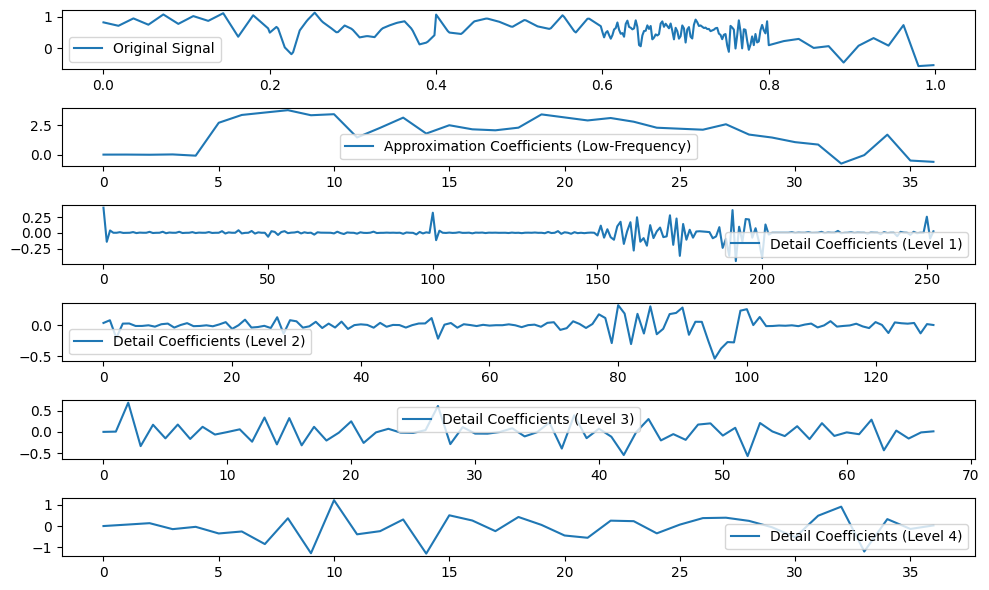

In [27]:
import torch
from torch import nn
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')
from pytorch_wavelets import DWT1D
np.random.seed(42)
np.random.seed(42)
t = np.linspace(0, 1, 500, endpoint=False)
signal_tensor = torch.tensor(signal[0], dtype=torch.float32).reshape(1, 1, 500)

print(signal_tensor.shape)
wavelet = 'db4'
wt = DWT1D(J=4,mode='zero',wave='db4')
yL, yH = wt(signal_tensor)

yL = yL.squeeze().detach().numpy()
yL = np.asarray(yL, dtype=np.float64) 
print(yL.shape)
print(len(yL))
yH = [yh.squeeze().detach().numpy() for yh in yH]
yH = [np.asarray(yh, dtype=np.float64) for yh in yH] 

df = pd.DataFrame({'Time': t, 'Original Signal': signal[0]})
df['Low Frequency'] = np.interp(t, np.linspace(0, 1, yL.shape[0], dtype=np.float64), yL)

for i, yh in enumerate(yH):
    df[f'Detail {i+1}'] = np.interp(t, np.linspace(0, 1, len(yh)), yh)

df.to_csv("wavelet_decomposition.csv", index=False)

print("数据已保存，可在 Origin 中打开 wavelet_decomposition.csv")
plt.figure(figsize=(10, 6))
plt.subplot(6, 1, 1)
plt.plot(t, signal[0], label="Original Signal")
plt.legend()
plt.subplot(6, 1, 2)
plt.plot(yL, label="Approximation Coefficients (Low-Frequency)")
plt.legend()
for i, yh in enumerate(yH):
    plt.subplot(6, 1, i+3)
    plt.plot(yh, label=f'Detail Coefficients (Level {i+1})')
    plt.legend()
plt.tight_layout()
plt.show()
